# Variational Autoencoder (VAE) on MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## Load Dataset and Create Validation Split

In [2]:
transform = transforms.ToTensor()

dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


## Define VAE Model

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

## Loss Function

In [4]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

## Initialize Model

In [5]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training with Early Stopping

In [10]:
epochs = 50
patience = 5
best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

train_recon_losses = []
train_kl_losses = []
val_recon_losses = []
val_kl_losses = []

for epoch in range(epochs):
    model.train()
    train_total_loss = 0
    train_epoch_recon_loss = 0
    train_epoch_kl_loss = 0

    for data,_ in train_loader:
        data = data.view(data.size(0), -1).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        total_loss, recon_loss, kl_loss = vae_loss(recon,data,mu,logvar)

        total_loss.backward()
        optimizer.step()

        train_total_loss += total_loss.item()
        train_epoch_recon_loss += recon_loss.item()
        train_epoch_kl_loss += kl_loss.item()

    model.eval()
    val_total_loss = 0
    val_epoch_recon_loss = 0
    val_epoch_kl_loss = 0

    with torch.no_grad():
        for data,_ in val_loader:
            data = data.view(data.size(0), -1).to(device)
            recon, mu, logvar = model(data)
            total_loss, recon_loss, kl_loss = vae_loss(recon,data,mu,logvar)
            val_total_loss += total_loss.item()
            val_epoch_recon_loss += recon_loss.item()
            val_epoch_kl_loss += kl_loss.item()

    train_losses.append(train_total_loss)
    val_losses.append(val_total_loss)
    train_recon_losses.append(train_epoch_recon_loss)
    train_kl_losses.append(train_epoch_kl_loss)
    val_recon_losses.append(val_epoch_recon_loss)
    val_kl_losses.append(val_epoch_kl_loss)

    print(f"Epoch {epoch+1} | Train Loss: {train_total_loss:.2f} (Recon: {train_epoch_recon_loss:.2f}, KL: {train_epoch_kl_loss:.2f}) | Val Loss: {val_total_loss:.2f} (Recon: {val_epoch_recon_loss:.2f}, KL: {val_epoch_kl_loss:.2f})")

    if val_total_loss < best_val_loss:
        best_val_loss = val_total_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print('Early stopping triggered')
        break

Epoch 1 | Train Loss: 5504179.27 (Recon: 4134865.63, KL: 1369313.64) | Val Loss: 617790.97 (Recon: 466099.15, KL: 151691.83)
Epoch 2 | Train Loss: 5500102.97 (Recon: 4131890.09, KL: 1368212.89) | Val Loss: 619761.32 (Recon: 462631.83, KL: 157129.49)
Epoch 3 | Train Loss: 5499205.91 (Recon: 4130506.64, KL: 1368699.26) | Val Loss: 618113.55 (Recon: 469856.87, KL: 148256.68)
Epoch 4 | Train Loss: 5496379.42 (Recon: 4127646.34, KL: 1368733.07) | Val Loss: 618324.13 (Recon: 464214.33, KL: 154109.79)
Epoch 5 | Train Loss: 5494123.39 (Recon: 4127337.02, KL: 1366786.37) | Val Loss: 617686.24 (Recon: 467711.46, KL: 149974.78)
Epoch 6 | Train Loss: 5491785.73 (Recon: 4123835.17, KL: 1367950.57) | Val Loss: 617430.77 (Recon: 465073.49, KL: 152357.28)
Epoch 7 | Train Loss: 5491272.00 (Recon: 4123603.37, KL: 1367668.63) | Val Loss: 617894.96 (Recon: 463377.17, KL: 154517.78)
Epoch 8 | Train Loss: 5490423.25 (Recon: 4121488.61, KL: 1368934.64) | Val Loss: 618660.30 (Recon: 469586.90, KL: 149073.41)


## Plot Training vs Validation Loss

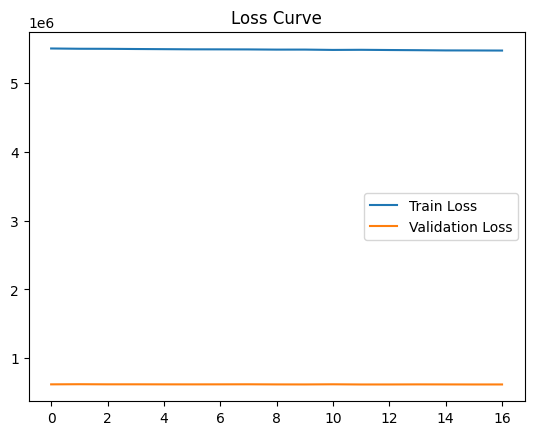

In [11]:
plt.figure()
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Validation Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

## Reconstruction Visualization

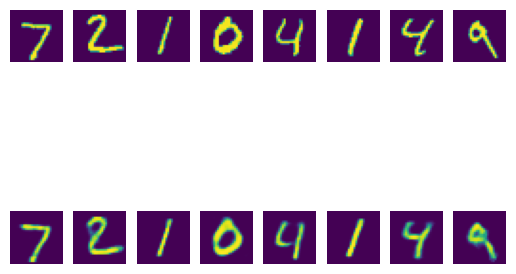

In [12]:
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8)

images,_ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    recon,_,_ = model(images.view(images.size(0),-1))

recon = recon.view(-1,1,28,28)

plt.figure()

for i in range(8):
    plt.subplot(2,8,i+1)
    plt.imshow(images[i].cpu().squeeze())
    plt.axis('off')

    plt.subplot(2,8,i+9)
    plt.imshow(recon[i].cpu().squeeze())
    plt.axis('off')

plt.show()

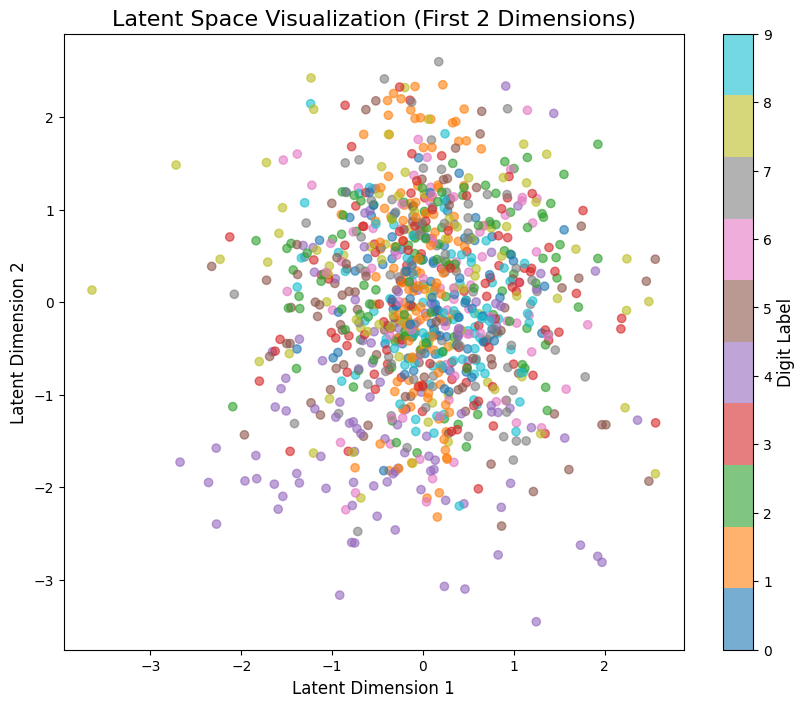

In [13]:
model.eval()
images, labels = next(iter(DataLoader(test_dataset, batch_size=1000)))

# Move the images to the appropriate device
images = images.to(device)

# Reshape the images to a 1D vector (flatten)
images = images.view(images.size(0), -1)

# Pass the reshaped images through the VAE model's encode method to obtain the mean (mu)
with torch.no_grad():
    mu, _ = model.encode(images)

# Convert the mu tensor and the labels tensor to NumPy arrays and move them to the CPU for plotting
mu_np = mu.cpu().numpy()
labels_np = labels.cpu().numpy()

# Create a scatter plot using matplotlib.pyplot.scatter()
plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_np[:, 0], mu_np[:, 1], c=labels_np, cmap='tab10', alpha=0.6)


plt.title('Latent Space Visualization (First 2 Dimensions)', fontsize=16)
plt.xlabel('Latent Dimension 1', fontsize=12)
plt.ylabel('Latent Dimension 2', fontsize=12);

# Add a color bar to indicate the mapping between colors and digit labels
cbar = plt.colorbar(scatter)
cbar.set_label('Digit Label', fontsize=12)
plt.show()

## Summary:

*   A scatter plot of the latent space (first two dimensions) was successfully generated using 1000 test images, with each point colored according to its MNIST digit label, effectively visualizing the separation of different digits in the latent space.
*   The training loop was modified to output detailed per-epoch loss metrics, including individual reconstruction and KL divergence losses for both the training and validation sets.
*   The training process utilized early stopping, which was triggered after Epoch 17, indicating that the model's performance on the validation set had ceased to improve significantly.


